# **프로젝트: Seq2Seq으로 한국어 번역기 만들기**

#### **1. 프로젝트 목적**
Bahdanau Attention 기반 GRU Seq2Seq 모델을 활용해 한국어 -> 영어 번역기를 구현한다.  

5단계 Ablation Study를 통해 vocab size / 모델 복잡도 / dropout / 양방향 GRU의 기여도를 단계적으로 분리해 비교한다.  

<table style="margin-left:0">
<tr>
<th>실험</th><th>vocab</th><th>emb_dim</th><th>hid_dim</th><th>dropout</th><th>bidir</th>
</tr>
<tr><td>Exp1</td><td>10,000</td><td>128</td><td>256</td><td>0</td><td>✗</td></tr>
<tr><td>Exp2</td><td>15,000</td><td>128</td><td>256</td><td>0</td><td>✗</td></tr>
<tr><td>Exp3</td><td>15,000</td><td>256</td><td>512</td><td>0</td><td>✗</td></tr>
<tr><td>Exp4</td><td>best</td><td>256</td><td>512</td><td>0.3</td><td>✗</td></tr>
<tr><td>Exp5</td><td>best</td><td>256</td><td>512</td><td>0.3</td><td>✓</td></tr>
</table>

*루브릭에 없는 추가 실험 4, 5의 vocab/tokenizer/dataloader는 Exp1~3 중 최종 epoch loss가 가장 낮은 실험의 것을 사용한다.

#### **2. 데이터셋**
- 출처: [jungyeul/korean-parallel-corpora (korean-english-park.train.tar.gz)](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)

## 1. 라이브러리 불러오기

In [1]:
import os
import re
import tarfile
import urllib.request
import time
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}") # 폰트 확인

설정된 폰트: NanumBarunGothic


In [2]:
# 난수 고정
GLOBAL_SEED = 42  # 전역 시드 — 모든 난수 발생원을 이 값으로 초기화

def set_seed(seed: int = GLOBAL_SEED) -> None:
    """
    재현 가능한 실험을 위해 모든 난수 발생원을 고정한다.

    고정 대상:
        - Python 내장 random
        - NumPy
        - PyTorch CPU / GPU (단일·다중 GPU 모두)
        - CUDA 결정적 연산 모드 (cudnn.deterministic)

    Args:
        seed: 고정할 시드 값 (기본값: GLOBAL_SEED=42)

    Note:
        cudnn.deterministic=True 는 일부 연산에서 속도 저하를 유발할 수 있다.
        재현성보다 속도가 중요한 경우 해당 두 줄을 주석 처리한다.
    """
    import random
    random.seed(seed)                          # Python 내장 random
    np.random.seed(seed)                       # NumPy
    torch.manual_seed(seed)                    # PyTorch CPU 연산
    torch.cuda.manual_seed(seed)              # 단일 GPU
    torch.cuda.manual_seed_all(seed)          # 다중 GPU (DataParallel 등)
    torch.backends.cudnn.deterministic = True  # CUDA 결정적 연산 강제
    torch.backends.cudnn.benchmark     = False # 자동 커널 탐색 비활성 (재현성 우선)
    print(f"시드 고정 완료 (seed={seed})")

# 전역 시드 고정
set_seed(GLOBAL_SEED)

시드 고정 완료 (seed=42)


In [3]:
# GPU / CPU 자동 선택
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


## 2. 전처리 함수 정의

In [4]:
def download_data(dataset_dir: str = "./datasets") -> tuple[list[str], list[str]]:
    """
    jungyeul/korean-parallel-corpora 한영 병렬 데이터를 다운로드한다.

    Args:
        dataset_dir: 데이터 저장 디렉터리

    Returns:
        (kor_lines, eng_lines): 줄 단위 한/영 문장 리스트
    """
    os.makedirs(dataset_dir, exist_ok=True)
    tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")
    url = (
        "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora"
        "/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    )
    if not os.path.exists(tar_path):
        print("데이터 다운로드 중 ...")
        urllib.request.urlretrieve(url, tar_path)
        print("다운로드 완료!")

    extract_dir = os.path.join(dataset_dir, "korean-english-park")
    if not os.path.exists(extract_dir):
        print("압축 해제 중 ...")
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(dataset_dir)
        print("압축 해제 완료!")

    kor_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
    eng_path = os.path.join(dataset_dir, "korean-english-park.train.en")
    with open(kor_path, "r", encoding="utf-8") as f:
        kor_lines = f.read().strip().split("\n")
    with open(eng_path, "r", encoding="utf-8") as f:
        eng_lines = f.read().strip().split("\n")

    print(f"총 문장 수: {len(kor_lines)}")
    return kor_lines, eng_lines

In [5]:
def preprocessing(sentence: str, is_korean: bool = False) -> str:
    """
    문장 정제 함수
    - 공통  : 구두점 앞뒤 공백 추가, 연속 공백 제거
    - 영어  : 소문자 변환, 영문자·구두점 외 제거
    - 한국어: 한글(가-힣)·구두점 외 제거

    Args:
        sentence  : 원문 문자열
        is_korean : True이면 한국어 정규식 적용

    Returns:
        정제된 문자열
    """
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)  # 구두점 분리
    sentence = re.sub(r'[ "]+', " ", sentence)          # 연속 공백 제거
    if is_korean:
        sentence = re.sub(r"[^가-힣?.!,\s]+", " ", sentence)
    else:
        sentence = sentence.lower()
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    return sentence.strip()

In [6]:
def build_cleaned_corpus(
    kor_lines: list[str],
    eng_lines: list[str],
) -> list[tuple[str, str]]:
    """
    중복 제거 병렬 코퍼스를 반환한다.
    set을 이용해 (한국어, 영어) 쌍 단위로 중복을 제거하므로
    병렬 쌍이 흐트러지지 않는다.

    Args:
        kor_lines: 한국어 원문 리스트
        eng_lines: 영어 원문 리스트

    Returns:
        cleaned_corpus: [(kor, eng), ...] 정제된 병렬 쌍 리스트
    """
    seen, cleaned_corpus = set(), []
    for kor, eng in zip(kor_lines, eng_lines):
        pair = (kor.strip(), eng.strip())
        if pair not in seen:
            seen.add(pair)
            cleaned_corpus.append(pair)
    print(f"중복 제거 후 문장 수: {len(cleaned_corpus)}")
    return cleaned_corpus

In [7]:
def tokenize_corpus(
    cleaned_corpus: list[tuple[str, str]],
    max_token_len:  int = 40,
) -> tuple[list[str], list[str]]:
    """
    한국어는 KoNLPy Mecab으로 형태소 분석,
    영어는 <start>/<end> 추가 후 공백 분리한다.
    두 언어 모두 max_token_len 이하인 쌍만 선별한다.

    Args:
        cleaned_corpus: build_cleaned_corpus() 반환값
        max_token_len : 최대 허용 토큰 수

    Returns:
        (kor_corpus, eng_corpus): 토큰화된 문장 리스트 (공백 구분 문자열)
    """
    try:
        from konlpy.tag import Mecab
        mecab    = Mecab()
        use_mecab = True
        print("Mecab 로드 성공")
    except Exception:
        print("Mecab 로드 실패 -> 공백 분리로 대체")
        use_mecab = False

    kor_corpus, eng_corpus = [], []
    for kor_raw, eng_raw in cleaned_corpus:
        kor_clean  = preprocessing(kor_raw, is_korean=True)
        kor_tokens = mecab.morphs(kor_clean) if use_mecab else kor_clean.split()

        eng_clean  = preprocessing(eng_raw, is_korean=False)
        eng_tokens = ["<start>"] + eng_clean.split() + ["<end>"]

        if len(kor_tokens) <= max_token_len and len(eng_tokens) <= max_token_len:
            kor_corpus.append(" ".join(kor_tokens))
            eng_corpus.append(" ".join(eng_tokens))

    print(f"필터링 후 문장 수: {len(kor_corpus)}")
    return kor_corpus, eng_corpus

In [8]:
class SimpleTokenizer:
    """
    단어 단위 토크나이저.
    특수 토큰: <pad>=0, <unk>=1
    """
    PAD_TOKEN = "<pad>"
    UNK_TOKEN = "<unk>"

    def __init__(self, num_words: int = 15000):
        """
        Args:
            num_words: 최대 어휘 수 (빈도 상위 n개)
        """
        self.num_words   = num_words
        self.word2idx:   dict[str, int] = {}
        self.idx2word:   dict[int, str] = {}
        self.word_counts: dict[str, int] = {}

    def fit(self, sentences: list[str]) -> None:
        """빈도 기반 어휘 사전 구축."""
        for sentence in sentences:
            for word in sentence.split():
                self.word_counts[word] = self.word_counts.get(word, 0) + 1
        sorted_words = sorted(self.word_counts, key=self.word_counts.get, reverse=True)
        vocab = [self.PAD_TOKEN, self.UNK_TOKEN] + sorted_words[: self.num_words - 2]
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        self.idx2word = {i: w for i, w in enumerate(vocab)}

    def encode(self, sentence: str) -> list[int]:
        """문자열 → 인덱스 리스트."""
        unk = self.word2idx[self.UNK_TOKEN]
        return [self.word2idx.get(w, unk) for w in sentence.split()]

    def decode(self, indices: list[int]) -> str:
        """인덱스 리스트 → 문자열."""
        return " ".join(self.idx2word.get(i, self.UNK_TOKEN) for i in indices)

    def __len__(self) -> int:
        return len(self.word2idx)

In [9]:
def tokenize(
    corpus:    list[str],
    num_words: int = 15000,
) -> tuple[torch.Tensor, SimpleTokenizer]:
    """
    코퍼스를 학습해 패딩된 텐서와 tokenizer를 반환한다.

    Args:
        corpus    : 공백 구분 문자열 리스트
        num_words : 최대 어휘 수 (최소 10,000 이상 권장)

    Returns:
        (tensor, tokenizer)
    """
    tokenizer = SimpleTokenizer(num_words=num_words)
    tokenizer.fit(corpus)
    encoded = [tokenizer.encode(s) for s in corpus]
    max_len = max(len(e) for e in encoded)
    padded  = [e + [0] * (max_len - len(e)) for e in encoded]
    tensor  = torch.tensor(padded, dtype=torch.long)
    print(f"  어휘 수: {len(tokenizer):,}  텐서 크기: {tensor.shape}")
    return tensor, tokenizer

In [10]:
class TranslationDataset(Dataset):
    """
    한→영 번역 Dataset.
    - src       : 패딩된 한국어 인덱스 시퀀스
    - trg_input : <start>…<end> 포함 영어 입력 시퀀스
    - trg_label : trg_input의 1-step left-shift (정답 레이블)
    """
    def __init__(
        self,
        kor_corpus:    list[str],
        eng_corpus:    list[str],
        kor_tokenizer: SimpleTokenizer,
        eng_tokenizer: SimpleTokenizer,
        max_len:       int = 40,
    ):
        self.kor_corpus    = kor_corpus
        self.eng_corpus    = eng_corpus
        self.kor_tokenizer = kor_tokenizer
        self.eng_tokenizer = eng_tokenizer
        self.max_len       = max_len
        self.pad_id        = 0
        self.bos_id        = eng_tokenizer.word2idx.get("<start>", 1)
        self.eos_id        = eng_tokenizer.word2idx.get("<end>",   2)

    def __len__(self) -> int:
        return len(self.kor_corpus)

    def __getitem__(self, idx: int):
        src_ids   = self.kor_tokenizer.encode(self.kor_corpus[idx])[: self.max_len]
        trg_ids   = self.eng_tokenizer.encode(self.eng_corpus[idx])
        trg_input = [self.bos_id] + trg_ids[: self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[: self.max_len - 1] + [self.eos_id]

        # 패딩
        pad = self.pad_id
        src_ids   = src_ids   + [pad] * (self.max_len - len(src_ids))
        trg_input = trg_input + [pad] * (self.max_len - len(trg_input))
        trg_label = trg_label + [pad] * (self.max_len - len(trg_label))

        return (
            torch.tensor(src_ids,   dtype=torch.long),
            torch.tensor(trg_input, dtype=torch.long),
            torch.tensor(trg_label, dtype=torch.long),
        )

In [11]:
def build_dataloader(
    kor_corpus: list[str],
    eng_corpus: list[str],
    num_words:  int = 15000,
    max_len:    int = 40,
    batch_size: int = 64,
) -> tuple[DataLoader, SimpleTokenizer, SimpleTokenizer]:
    """
    vocab_size 하나로 tokenizer 구축 → Dataset → DataLoader까지 일괄 생성.
    worker별 난수 시드도 내부에서 고정한다.

    Args:
        kor_corpus : 한국어 토큰화 문장 리스트
        eng_corpus : 영어 토큰화 문장 리스트
        num_words  : vocab 크기
        max_len    : 최대 시퀀스 길이
        batch_size : 배치 크기

    Returns:
        (dataloader, kor_tokenizer, eng_tokenizer)
    """
    print(f"\n[build_dataloader] vocab={num_words:,}")
    print("  한국어 tokenizer 구축 중 ...")
    _, kor_tokenizer = tokenize(kor_corpus, num_words=num_words)
    print("  영어 tokenizer 구축 중 ...")
    _, eng_tokenizer = tokenize(eng_corpus, num_words=num_words)

    dataset = TranslationDataset(
        kor_corpus, eng_corpus,
        kor_tokenizer, eng_tokenizer,
        max_len=max_len,
    )

    def worker_init_fn(worker_id: int) -> None:
        """worker별 독립 시드 고정 (재현성 보장)."""
        ws = GLOBAL_SEED + worker_id
        random.seed(ws); np.random.seed(ws); torch.manual_seed(ws)

    g = torch.Generator()
    g.manual_seed(GLOBAL_SEED)

    dataloader = DataLoader(
        dataset,
        batch_size     = batch_size,
        shuffle        = True,
        num_workers    = 2,
        pin_memory     = True,
        generator      = g,
        worker_init_fn = worker_init_fn,
    )
    print(f"  DataLoader 완료 — {len(dataset):,}샘플 / {len(dataloader)}스텝/에폭")
    return dataloader, kor_tokenizer, eng_tokenizer

## 3. 모델 정의

In [12]:
class BahdanauAttention(nn.Module):
    """
    Additive Attention
    디코더 hidden s_{t-1}과 인코더 출력 H를 비교해 attention 분포를 계산한다
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)  # 인코더 출력 변환
        self.W2 = nn.Linear(hidden_dim, hidden_dim)  # 디코더 hidden 변환
        self.v  = nn.Linear(hidden_dim, 1, bias=False)  # 스칼라 에너지

    def forward(
        self,
        hidden:          torch.Tensor,  # (batch, hid)
        encoder_outputs: torch.Tensor,  # (src_len, batch, hid)
    ) -> torch.Tensor:                  # → (batch, src_len)
        src_len         = encoder_outputs.shape[0]
        hidden          = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch, src_len, hid)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)           # (batch, src_len, hid)
        energy          = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention       = self.v(energy).squeeze(2)                  # (batch, src_len)
        return nn.functional.softmax(attention, dim=1)

In [13]:
class Encoder(nn.Module):
    """
    단방향 GRU 인코더 (Exp1·2·3·4)
    GRU는 (outputs, hidden)만 반환 — cell state 없음 (LSTM과 다름)
    """
    def __init__(self, input_dim: int, emb_dim: int, hidden_dim: int, dropout: float = 0.0):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor):
        # src: (src_len, batch)
        embedded        = self.dropout(self.embedding(src))  # (src_len, batch, emb)
        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch, hid) / hidden: (1, batch, hid)
        return outputs, hidden

In [14]:
class BidirectionalEncoder(nn.Module):
    """
    양방향 GRU 인코더
    한국어 SOV 어순에서 동사가 문장 끝에 위치하므로
    역방향 독해로 컨텍스트 품질을 높인다.
    양방향 출력(2*hid)을 디코더 hid_dim으로 선형 투영한다.
    """
    def __init__(self, input_dim: int, emb_dim: int, hidden_dim: int, dropout: float = 0.0):
        super().__init__()
        self.embedding  = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn        = nn.GRU(emb_dim, hidden_dim, bidirectional=True)
        self.dropout    = nn.Dropout(dropout)
        self.fc_hidden  = nn.Linear(hidden_dim * 2, hidden_dim)  # hidden 투영
        self.fc_outputs = nn.Linear(hidden_dim * 2, hidden_dim)  # outputs 투영

    def forward(self, src: torch.Tensor):
        embedded        = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # hidden: (2, batch, hid) → concat → (batch, 2*hid) → 투영 → (1, batch, hid)
        hidden  = torch.tanh(
            self.fc_hidden(torch.cat((hidden[-2], hidden[-1]), dim=1))
        ).unsqueeze(0)
        outputs = torch.tanh(self.fc_outputs(outputs))  # (src_len, batch, hid)
        return outputs, hidden

In [15]:
class Decoder(nn.Module):
    """
    Attention 기반 GRU 디코더
    각 스텝: 임베딩 -> Attention context 계산 -> GRU -> hidden+context 결합 -> 예측
    디코더는 단어를 순서대로 생성하므로 단방향 GRU만 사용한다.
    """
    def __init__(
        self,
        output_dim: int,
        emb_dim:    int,
        hidden_dim: int,
        attention:  BahdanauAttention,
        dropout:    float = 0.0,
    ):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn       = nn.GRU(emb_dim, hidden_dim)
        self.fc_out    = nn.Linear(hidden_dim * 2, output_dim)  # hidden + context
        self.dropout   = nn.Dropout(dropout)

    def forward(
        self,
        input:           torch.Tensor,  # (batch,)
        hidden:          torch.Tensor,  # (1, batch, hid)
        encoder_outputs: torch.Tensor,  # (src_len, batch, hid)
    ):
        input    = input.unsqueeze(0)                                   # (1, batch)
        embedded = self.dropout(self.embedding(input))                  # (1, batch, emb)

        a        = self.attention(hidden[-1], encoder_outputs)          # (batch, src_len)
        context  = torch.bmm(
            a.unsqueeze(1),
            encoder_outputs.permute(1, 0, 2)
        ).permute(1, 0, 2)                                              # (1, batch, hid)

        output, hidden = self.rnn(embedded, hidden)                     # (1, batch, hid)

        prediction = self.fc_out(
            torch.cat((output.squeeze(0), context.squeeze(0)), dim=1)
        )                                                               # (batch, out_dim)
        return prediction, hidden, a

In [16]:
class Seq2SeqAttention(nn.Module):
    """
    Encoder–Decoder Seq2Seq 모델
    - 훈련 (trg 제공) : Teacher Forcing
    - 추론 (trg=None) : 자기회귀 생성 + EOS 조기 종료
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(
        self,
        src:     torch.Tensor,
        trg:     torch.Tensor | None = None,
        max_len: int = 40,
        bos_id:  int = 1,
        eos_id:  int = 2,
    ):
        batch_size = src.shape[1]
        outputs, attentions = [], []
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 훈련: 정답 토큰을 매 스텝 디코더 입력으로 사용
            for t in range(trg.shape[0]):
                out, hidden, attn = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
        else:
            # 추론: 이전 예측 토큰을 다음 입력으로 피드백
            inp      = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for _ in range(max_len):
                out, hidden, attn = self.decoder(inp, hidden, encoder_outputs)
                outputs.append(out.unsqueeze(0))
                attentions.append(attn.unsqueeze(0))
                inp       = out.argmax(1)
                finished |= (inp == eos_id)
                if finished.all():
                    break

        return torch.cat(outputs, dim=0), torch.cat(attentions, dim=0)

In [17]:
# 모델 빌더 정의
def build_model(
    input_dim:     int,
    output_dim:    int,
    emb_dim:       int   = 256,
    hid_dim:       int   = 512,
    dropout:       float = 0.0,
    bidirectional: bool  = False,
) -> Seq2SeqAttention:
    """
    실험 설정에 맞는 Seq2SeqAttention 모델을 생성한다.

    Args:
        input_dim     : 소스(한국어) 어휘 크기
        output_dim    : 타겟(영어) 어휘 크기
        emb_dim       : 임베딩 차원
        hid_dim       : GRU hidden 차원
        dropout       : dropout 비율
        bidirectional : True → BidirectionalEncoder 사용

    Returns:
        device에 올라간 Seq2SeqAttention 모델
    """
    attn = BahdanauAttention(hid_dim).to(device)
    enc  = (BidirectionalEncoder if bidirectional else Encoder)(
        input_dim, emb_dim, hid_dim, dropout
    ).to(device)
    dec  = Decoder(output_dim, emb_dim, hid_dim, attn, dropout).to(device)
    model = Seq2SeqAttention(enc, dec, device).to(device)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  파라미터 수: {n_params:,}")
    return model

## 4. 학습 관련 함수 정의

In [18]:
def train_step(
    model:       Seq2SeqAttention,
    data_loader: DataLoader,
    optimizer:   torch.optim.Optimizer,
    criterion:   nn.Module,
    epoch:       int,
) -> float:
    """
    1 에폭 학습을 수행하고 평균 loss를 반환한다.

    Args:
        model       : Seq2SeqAttention
        data_loader : 훈련용 DataLoader
        optimizer   : 옵티마이저
        criterion   : 손실 함수
        epoch       : 현재 에폭 번호 (tqdm 표시용)

    Returns:
        에폭 평균 loss
    """
    model.train()
    epoch_loss = 0
    bar = tqdm(data_loader, desc=f"Epoch {epoch + 1}", leave=True)

    for src, trg_input, trg_label in bar:
        # (batch, seq) → (seq, batch): RNN 입력 규격
        src       = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)

        # (trg_len, batch, vocab) → (trg_len*batch, vocab)
        loss = criterion(
            outputs.reshape(-1, outputs.shape[-1]),
            trg_label.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        bar.set_postfix(loss=f"{loss.item():.4f}")

    return epoch_loss / len(data_loader)

In [19]:
def run_experiment(
    exp:           dict,
    kor_corpus:    list[str],
    eng_corpus:    list[str],
    test_sentences: list[str],
    epochs:        int = 20,
    batch_size:    int = 64,
    lr:            float = 1e-3,
    max_len:       int = 40,
    # 외부에서 tokenizer/dataloader를 주입할 때 사용
    kor_tokenizer: SimpleTokenizer | None = None,
    eng_tokenizer: SimpleTokenizer | None = None,
    dataloader:    DataLoader       | None = None,
) -> dict:
    """
    단일 실험을 처음부터 끝까지 실행하고 결과 dict를 반환한다.

    - tokenizer/dataloader가 None이면 exp["num_words"]로 새로 구축한다.
    - 외부에서 주입되면 그대로 재사용한다 (Exp4·5의 best tokenizer 재사용).
    - 모든 실험은 GLOBAL_SEED로 시작해 초기화 조건을 통제한다.

    Args:
        exp            : 실험 설정 dict
                         (name, num_words, emb_dim, hid_dim, dropout, bidirectional)
        kor_corpus     : 한국어 코퍼스
        eng_corpus     : 영어 코퍼스
        test_sentences : 에폭마다 번역 확인할 예문 리스트
        epochs         : 학습 에폭 수
        batch_size     : 배치 크기
        lr             : 학습률
        max_len        : 최대 시퀀스 길이
        kor_tokenizer  : 재사용할 한국어 tokenizer (None이면 새로 구축)
        eng_tokenizer  : 재사용할 영어 tokenizer   (None이면 새로 구축)
        dataloader     : 재사용할 DataLoader        (None이면 새로 구축)

    Returns:
        result dict:
            name, loss_history, final_loss,
            kor_tokenizer, eng_tokenizer, dataloader, model
    """
    print("\n" + "=" * 70)
    print(f"  실험: {exp['name']}")
    print(f"  vocab={exp['num_words']:,}  emb={exp['emb_dim']}  "
          f"hid={exp['hid_dim']}  dropout={exp['dropout']}  "
          f"bidir={exp['bidirectional']}")
    print("=" * 70)

    # tokenizer / dataloader 준비
    if dataloader is None:
        # 새로 구축 (Exp1·2·3)
        dataloader, kor_tokenizer, eng_tokenizer = build_dataloader(
            kor_corpus, eng_corpus,
            num_words  = exp["num_words"],
            max_len    = max_len,
            batch_size = batch_size,
        )
    else:
        # 외부 주입 재사용 (Exp4, 5 — best tokenizer)
        print(f"  ✓ best tokenizer 재사용 (vocab={len(kor_tokenizer):,})")

    # 시드 고정 -> 모델 초기화
    set_seed(GLOBAL_SEED)
    model = build_model(
        input_dim     = len(kor_tokenizer),
        output_dim    = len(eng_tokenizer),
        emb_dim       = exp["emb_dim"],
        hid_dim       = exp["hid_dim"],
        dropout       = exp["dropout"],
        bidirectional = exp["bidirectional"],
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # <pad>=0 무시

    loss_history = []
    t0           = time.time()

    for epoch in range(epochs):
        train_loss = train_step(model, dataloader, optimizer, criterion, epoch)
        loss_history.append(train_loss)
        print(f"Epoch {epoch + 1}/{epochs}  Train Loss: {train_loss:.4f}")
    
        # 5 에폭마다 + 마지막 에폭에 예문 번역 출력
        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            print("  [ 예문 번역 ]")
            for sent in test_sentences:
                tokens, _, _ = translate_sentence(
                    sent, model, kor_tokenizer, eng_tokenizer, max_len=max_len
                )
                print(f"  KOR: {sent}  →  ENG: {' '.join(tokens)}")
            print()

    elapsed = time.time() - t0
    print(f"총 학습 시간: {elapsed / 60:.1f}분")

    # 모델 저장
    torch.save(model.state_dict(), f"{exp['name']}_model.pt")
    print(f"모델 저장: {exp['name']}_model.pt")

    return {
        "name":          exp["name"],
        "loss_history":  loss_history,
        "final_loss":    loss_history[-1],  # best 선택 기준
        "kor_tokenizer": kor_tokenizer,
        "eng_tokenizer": eng_tokenizer,
        "dataloader":    dataloader,
        "model":         model,
    }

In [20]:
def translate_sentence(
    sentence:      str,
    model:         Seq2SeqAttention,
    kor_tokenizer: SimpleTokenizer,
    eng_tokenizer: SimpleTokenizer,
    max_len:       int = 40,
) -> tuple[list[str], str, np.ndarray]:
    """
    한국어 문장을 영어로 번역한다.

    Args:
        sentence      : 번역할 한국어 문장
        model         : 학습된 Seq2SeqAttention
        kor_tokenizer : 한국어 tokenizer
        eng_tokenizer : 영어 tokenizer
        max_len       : 최대 생성 길이

    Returns:
        (result_tokens, cleaned_sentence, attention_numpy)
    """
    model.eval()
    cleaned   = preprocessing(sentence, is_korean=True)
    src_ids   = kor_tokenizer.encode(cleaned)
    src_ids   = src_ids[:max_len] + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(
            src_tensor, max_len=max_len,
            bos_id = eng_tokenizer.word2idx.get("<start>", 1),
            eos_id = eng_tokenizer.word2idx.get("<end>",   2),
        )

    predicted_ids = outputs.argmax(2).squeeze(1).cpu().tolist()
    result_tokens = [eng_tokenizer.idx2word.get(i, "<unk>") for i in predicted_ids]
    if "<end>" in result_tokens:
        result_tokens = result_tokens[: result_tokens.index("<end>")]

    return result_tokens, cleaned, attentions.squeeze(1).cpu().numpy()

In [21]:
def plot_attention(
    attention:        np.ndarray,
    src_tokens:       list[str],
    predicted_tokens: list[str],
    title:            str = "Attention Map",
) -> None:
    """
    Attention Map을 히트맵으로 저장·출력한다.

    Args:
        attention        : (trg_len, src_len) attention 행렬
        src_tokens       : 소스 토큰 리스트 (x축)
        predicted_tokens : 예측 토큰 리스트 (y축)
        title            : 그래프 제목 및 저장 파일명 기준
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.matshow(attention, cmap="viridis")
    fig.colorbar(cax)
    ax.set_title(title, pad=20)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, fontsize=11)
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontsize=11)
    plt.tight_layout()
    fname = f"{title.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Attention Map 저장: {fname}")

In [22]:
def translate_and_show(
    sentence:      str,
    model:         Seq2SeqAttention,
    kor_tokenizer: SimpleTokenizer,
    eng_tokenizer: SimpleTokenizer,
    max_len:       int = 40,
    title:         str = "Attention Map",
) -> None:
    """번역 결과와 Attention Map을 함께 출력한다."""
    result, cleaned, attention = translate_sentence(
        sentence, model, kor_tokenizer, eng_tokenizer, max_len
    )
    print(f"Input      : {sentence}")
    print(f"Cleaned    : {cleaned}")
    print(f"Translation: {' '.join(result)}")

    src_tokens = cleaned.split()
    attn_slice = attention[: len(result), : len(src_tokens)]
    if attn_slice.size > 0:
        plot_attention(attn_slice, src_tokens, result, title=title)

## 5. 실험 진행

### 5-1. 데이터 다운로드 및 정제

In [23]:
MAX_LEN = 40

kor_lines, eng_lines = download_data()
cleaned_corpus       = build_cleaned_corpus(kor_lines, eng_lines)
kor_corpus, eng_corpus = tokenize_corpus(cleaned_corpus, max_token_len=MAX_LEN)

# 정제·토큰화 샘플 확인
print("\n[정제 전후 비교]")
kor_raw, eng_raw = cleaned_corpus[0]
print(f"  원문  KOR : {kor_raw}")
print(f"  정제  KOR : {preprocessing(kor_raw, is_korean=True)}")
print(f"  원문  ENG : {eng_raw}")
print(f"  정제  ENG : {preprocessing(eng_raw, is_korean=False)}")

print("\n[토큰화 샘플]")
for k, e in zip(kor_corpus[:3], eng_corpus[:3]):
    print(f"  KOR: {k}")
    print(f"  ENG: {e}\n")

압축 해제 중 ...


/tmp/ipykernel_7242/2036811545.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


압축 해제 완료!
총 문장 수: 94123
중복 제거 후 문장 수: 78941
Mecab 로드 성공
필터링 후 문장 수: 63099

[정제 전후 비교]
  원문  KOR : 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
  정제  KOR : 개인용 컴퓨터 사용의 상당 부분은 이것보다 뛰어날 수 있느냐 ?
  원문  ENG : Much of personal computing is about "can you top this?"
  정제  ENG : much of personal computing is about can you top this ?

[토큰화 샘플]
  KOR: 개인 용 컴퓨터 사용 의 상당 부분 은 이것 보다 뛰어날 수 있 느냐 ?
  ENG: <start> much of personal computing is about can you top this ? <end>

  KOR: 모든 광 마우스 와 마찬가지 로 이 광 마우스 도 책상 위 에 놓 는 마우스 패드 를 필요 로 하 지 않 는다 .
  ENG: <start> so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse . <end>

  KOR: 그러나 이것 은 또한 책상 도 필요 로 하 지 않 는다 .
  ENG: <start> like all optical mice , but it also doesn t need a desk . <end>



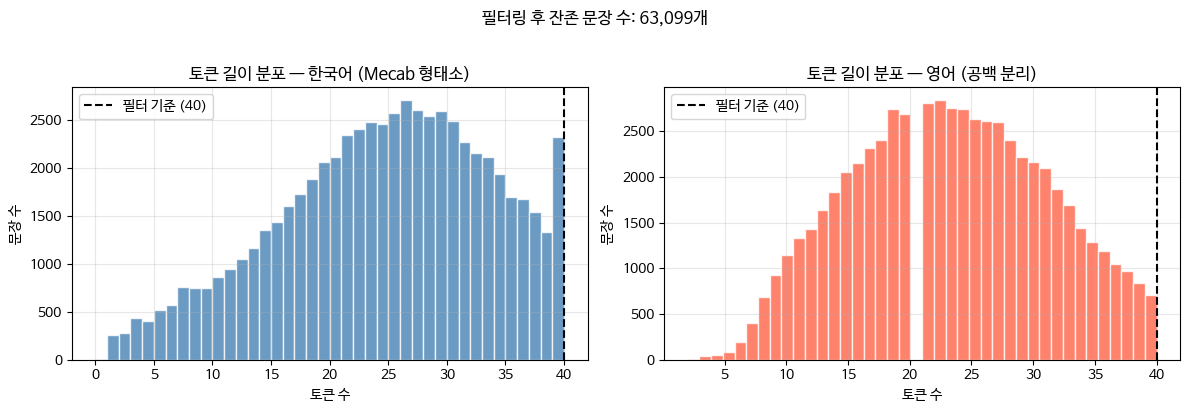

In [28]:
# 토큰 길이 분포 시각화
kor_lengths = [len(s.split()) for s in kor_corpus]
eng_lengths = [len(s.split()) for s in eng_corpus]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, lengths, label, color in zip(
    axes,
    [kor_lengths, eng_lengths],
    ["한국어 (Mecab 형태소)", "영어 (공백 분리)"],
    ["steelblue", "tomato"],
):
    ax.hist(lengths, bins=40, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(x=MAX_LEN, color="black", linestyle="--", linewidth=1.5,
               label=f"필터 기준 ({MAX_LEN})")
    ax.set_title(f"토큰 길이 분포 — {label}")
    ax.set_xlabel("토큰 수")
    ax.set_ylabel("문장 수")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f"필터링 후 잔존 문장 수: {len(kor_corpus):,}개", y=1.02)
plt.tight_layout()
plt.savefig("token_length_distribution.png", dpi=150)
plt.show()

한국어는 Mecab 형태소 분석으로 인해 분포가 20\~30 토큰 구간에 집중된 반면, 영어는 공백 분리 기준으로 15\~25 구간에 더 좁게 분포한다.

두 언어의 토큰 수 분포가 크게 벗어나지 않는 범위에 걸쳐 있어 병렬 쌍의 길이 균형이 잘 맞는 편이다.

**Teacher Forcing 학습 구조에서, 병렬 쌍의 길이 균형이 맞다는 것은 PAD 비율이 낮아지고 배치당 유효한 학습 신호가 많아져서 같은 에폭 수로도 더 효율적으로 학습할 수 있다는 장점이 있다.**

### 5-2. 실험 진행

In [31]:
# 실험 설정 및 하이퍼파라미터
BATCH_SIZE = 64
EPOCHS     = 20
LR         = 1e-3

TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

# Phase 1: 하이퍼파라미터 탐색 (vocab·emb·hid 순차 증가)
PHASE1_EXPERIMENTS = [
    {"name": "Exp1_Baseline", "num_words": 10_000, "emb_dim": 128, "hid_dim": 256,
     "dropout": 0.0, "bidirectional": False},
    {"name": "Exp2_Vocab",    "num_words": 15_000, "emb_dim": 128, "hid_dim": 256,
     "dropout": 0.0, "bidirectional": False},
    {"name": "Exp3_Size",     "num_words": 15_000, "emb_dim": 256, "hid_dim": 512,
     "dropout": 0.0, "bidirectional": False},
]

# Phase 2: 구조 개선 (best tokenizer 재사용)
PHASE2_EXPERIMENTS = [
    {"name": "Exp4_Dropout", "num_words": None, "emb_dim": 256, "hid_dim": 512,
     "dropout": 0.3, "bidirectional": False},
    {"name": "Exp5_Bidir",   "num_words": None, "emb_dim": 256, "hid_dim": 512,
     "dropout": 0.3, "bidirectional": True},
]

# 설정 요약 출력
print("=" * 70)
print("  Ablation Study 실험 설정")
print("=" * 70)
print(f"  {'실험':<25} {'vocab':>7} {'emb':>5} {'hid':>5} {'drop':>5} {'bidir':>6}")
print("─" * 70)
for exp in PHASE1_EXPERIMENTS + PHASE2_EXPERIMENTS:
    vocab = f"{exp['num_words']:,}" if exp["num_words"] else "best"
    print(f"  {exp['name']:<25} {vocab:>7} {exp['emb_dim']:>5} "
          f"{exp['hid_dim']:>5} {exp['dropout']:>5} {str(exp['bidirectional']):>6}")

  Ablation Study 실험 설정
  실험                          vocab   emb   hid  drop  bidir
──────────────────────────────────────────────────────────────────────
  Exp1_Baseline              10,000   128   256   0.0  False
  Exp2_Vocab                 15,000   128   256   0.0  False
  Exp3_Size                  15,000   256   512   0.0  False
  Exp4_Dropout                 best   256   512   0.3  False
  Exp5_Bidir                   best   256   512   0.3   True


In [26]:
# Phase 1 — Exp1 학습
phase1_results = {}

result_exp1 = run_experiment(
    exp            = PHASE1_EXPERIMENTS[0],
    kor_corpus     = kor_corpus,
    eng_corpus     = eng_corpus,
    test_sentences = TEST_SENTENCES,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    lr             = LR,
    max_len        = MAX_LEN,
)
phase1_results[result_exp1["name"]] = result_exp1


  실험: Exp1_Baseline
  vocab=10,000  emb=128  hid=256  dropout=0.0  bidir=False

[build_dataloader] vocab=10,000
  한국어 tokenizer 구축 중 ...
  어휘 수: 10,000  텐서 크기: torch.Size([63099, 40])
  영어 tokenizer 구축 중 ...
  어휘 수: 10,000  텐서 크기: torch.Size([63099, 40])
  DataLoader 완료 — 63,099샘플 / 986스텝/에폭
시드 고정 완료 (seed=42)
  파라미터 수: 8,414,736


Epoch 1: 100%|██████████| 986/986 [01:37<00:00, 10.09it/s, loss=4.3072]


Epoch 1/20  Train Loss: 4.8354


Epoch 2: 100%|██████████| 986/986 [01:39<00:00,  9.94it/s, loss=3.9396]


Epoch 2/20  Train Loss: 3.9741


...

Epoch 18/20  Train Loss: 1.6835


Epoch 19: 100%|██████████| 986/986 [01:39<00:00,  9.89it/s, loss=1.6531]


Epoch 19/20  Train Loss: 1.6448


Epoch 20: 100%|██████████| 986/986 [01:39<00:00,  9.93it/s, loss=1.7150]


Epoch 20/20  Train Loss: 1.6049
  [ 예문 번역 ]
  KOR: 오바마는 대통령이다.  →  ENG: <start> <unk> <unk> , a year old tibetan times .
  KOR: 시민들은 도시 속에 산다.  →  ENG: <start> <unk> city , a city in the city , is also a major cities in the town of <unk> .
  KOR: 커피는 필요 없다.  →  ENG: <start> <unk> <unk> is a <unk> <unk>
  KOR: 일곱 명의 사망자가 발생했다.  →  ENG: <start> the <unk> of the <unk> , the world s largest <unk> , said it was not welcome the first lpga member of the plane .

총 학습 시간: 33.1분
모델 저장: Exp1_Baseline_model.pt


In [27]:
# Phase 1 — Exp2 학습
result_exp2 = run_experiment(
    exp            = PHASE1_EXPERIMENTS[1],
    kor_corpus     = kor_corpus,
    eng_corpus     = eng_corpus,
    test_sentences = TEST_SENTENCES,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    lr             = LR,
    max_len        = MAX_LEN,
)
phase1_results[result_exp2["name"]] = result_exp2


  실험: Exp2_Vocab
  vocab=15,000  emb=128  hid=256  dropout=0.0  bidir=False

[build_dataloader] vocab=15,000
  한국어 tokenizer 구축 중 ...
  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  영어 tokenizer 구축 중 ...
  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  DataLoader 완료 — 63,099샘플 / 986스텝/에폭
시드 고정 완료 (seed=42)
  파라미터 수: 12,259,736


Epoch 1: 100%|██████████| 986/986 [01:58<00:00,  8.35it/s, loss=4.3862]


Epoch 1/20  Train Loss: 5.0186


Epoch 2: 100%|██████████| 986/986 [01:57<00:00,  8.36it/s, loss=4.1194]


Epoch 2/20  Train Loss: 4.1039


...

Epoch 18/20  Train Loss: 1.5750


Epoch 19: 100%|██████████| 986/986 [01:57<00:00,  8.36it/s, loss=1.5533]


Epoch 19/20  Train Loss: 1.5313


Epoch 20: 100%|██████████| 986/986 [01:57<00:00,  8.38it/s, loss=1.6504]


Epoch 20/20  Train Loss: 1.4916
  [ 예문 번역 ]
  KOR: 오바마는 대통령이다.  →  ENG: <start> . <unk> <unk> , who is <unk> , <unk> <unk> , said the <unk> <unk> , which <unk> the middle class .
  KOR: 시민들은 도시 속에 산다.  →  ENG: <start> <unk> <unk> is the city s largest city in the town of <unk> .
  KOR: 커피는 필요 없다.  →  ENG: <start> we don t need to be a very <unk> job .
  KOR: 일곱 명의 사망자가 발생했다.  →  ENG: <start> a large spy plane was carried out by <unk> .

총 학습 시간: 39.4분
모델 저장: Exp2_Vocab_model.pt


In [28]:
# Phase 1 — Exp3 학습
result_exp3 = run_experiment(
    exp            = PHASE1_EXPERIMENTS[2],
    kor_corpus     = kor_corpus,
    eng_corpus     = eng_corpus,
    test_sentences = TEST_SENTENCES,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    lr             = LR,
    max_len        = MAX_LEN,
)
phase1_results[result_exp3["name"]] = result_exp3


  실험: Exp3_Size
  vocab=15,000  emb=256  hid=512  dropout=0.0  bidir=False

[build_dataloader] vocab=15,000
  한국어 tokenizer 구축 중 ...
  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  영어 tokenizer 구축 중 ...
  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  DataLoader 완료 — 63,099샘플 / 986스텝/에폭
시드 고정 완료 (seed=42)
  파라미터 수: 25,946,264


Epoch 1: 100%|██████████| 986/986 [04:15<00:00,  3.86it/s, loss=4.0331]


Epoch 1/20  Train Loss: 4.7331


Epoch 2: 100%|██████████| 986/986 [04:15<00:00,  3.85it/s, loss=3.7249]


Epoch 2/20  Train Loss: 3.6171


...

Epoch 18/20  Train Loss: 0.5994


Epoch 19: 100%|██████████| 986/986 [04:15<00:00,  3.85it/s, loss=0.6655]


Epoch 19/20  Train Loss: 0.5736


Epoch 20: 100%|██████████| 986/986 [04:15<00:00,  3.85it/s, loss=0.6553]


Epoch 20/20  Train Loss: 0.5525
  [ 예문 번역 ]
  KOR: 오바마는 대통령이다.  →  ENG: <start> <unk>
  KOR: 시민들은 도시 속에 산다.  →  ENG: <start> the <unk> of this year , i d hold back this morning , and they ve stopped checking for a few days , they knew all about them , <unk> said .
  KOR: 커피는 필요 없다.  →  ENG: <start> don t get carried away .
  KOR: 일곱 명의 사망자가 발생했다.  →  ENG: <start> nine south korean workers are running in the worst eight region to escape high school , a total of .

총 학습 시간: 85.4분
모델 저장: Exp3_Size_model.pt



[Phase 1 결과 요약]
  실험                                최종 Loss
────────────────────────────────────────────
  Exp1_Baseline                      1.6049
  Exp2_Vocab                         1.4916
  Exp3_Size                          0.5525  ← BEST

✓ best 실험: Exp3_Size
  vocab=15,000 → Exp4·5에서 재사용


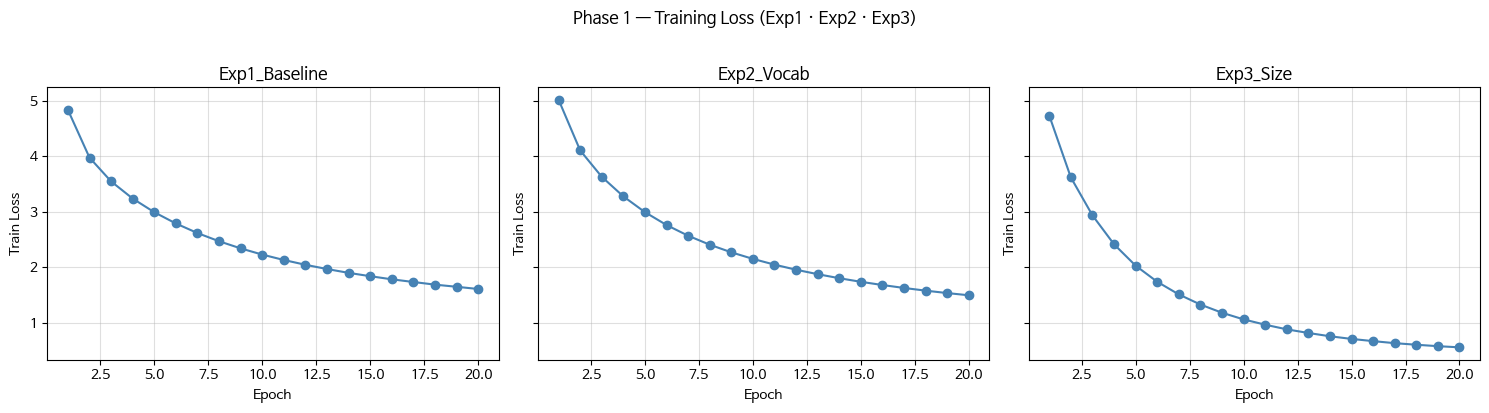

In [29]:
# hase 1 결과 비교 + best 자동 선택

# 최종 epoch loss 기준으로 best 실험 선택
best_name = min(phase1_results, key=lambda k: phase1_results[k]["final_loss"])
best      = phase1_results[best_name]

print("\n[Phase 1 결과 요약]")
print(f"  {'실험':<30} {'최종 Loss':>10}")
print("─" * 44)
for name, res in phase1_results.items():
    marker = "  ← BEST" if name == best_name else ""
    print(f"  {name:<30} {res['final_loss']:>10.4f}{marker}")
print(f"\n✓ best 실험: {best_name}")
print(f"  vocab={len(best['kor_tokenizer']):,} → Exp4·5에서 재사용")

# Phase 1 Loss 커브 — subplot(1, 3)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, res) in zip(axes, phase1_results.items()):
    epochs_range = range(1, len(res["loss_history"]) + 1)
    ax.plot(epochs_range, res["loss_history"], marker="o", linewidth=1.5, color="steelblue")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.grid(True, alpha=0.4)
plt.suptitle("Phase 1 — Training Loss (Exp1 · Exp2 · Exp3)", y=1.02)
plt.tight_layout()
plt.savefig("phase1_loss.png", dpi=150)
plt.show()

In [ ]:
# Phase 2 — Exp4 학습 (best tokenizer 재사용)
phase2_results = {}

result_exp4 = run_experiment(
    exp            = PHASE2_EXPERIMENTS[0],
    kor_corpus     = kor_corpus,
    eng_corpus     = eng_corpus,
    test_sentences = TEST_SENTENCES,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    lr             = LR,
    max_len        = MAX_LEN,
    kor_tokenizer  = best["kor_tokenizer"],
    eng_tokenizer  = best["eng_tokenizer"],
    dataloader     = best["dataloader"],
)
phase2_results[result_exp4["name"]] = result_exp4

In [ ]:
# Phase 2 — Exp5 학습 (best tokenizer 재사용)
result_exp5 = run_experiment(
    exp            = PHASE2_EXPERIMENTS[1],
    kor_corpus     = kor_corpus,
    eng_corpus     = eng_corpus,
    test_sentences = TEST_SENTENCES,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    lr             = LR,
    max_len        = MAX_LEN,
    kor_tokenizer  = best["kor_tokenizer"],
    eng_tokenizer  = best["eng_tokenizer"],
    dataloader     = best["dataloader"],
)
phase2_results[result_exp5["name"]] = result_exp5

In [ ]:
# Phase 2 결과 비교
print("\n[Phase 2 결과 요약]")
print(f"  {'실험':<30} {'최종 Loss':>10}")
print("─" * 44)
for name, res in phase2_results.items():
    print(f"  {name:<30} {res['final_loss']:>10.4f}")

# Phase 2 Loss 커브 — subplot(1, 2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (name, res) in zip(axes, phase2_results.items()):
    epochs_range = range(1, len(res["loss_history"]) + 1)
    ax.plot(epochs_range, res["loss_history"], marker="o", linewidth=1.5, color="tomato")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss")
    ax.grid(True, alpha=0.4)
plt.suptitle("Phase 2 — Training Loss (Exp4 · Exp5)", y=1.02)
plt.tight_layout()
plt.savefig("phase2_loss.png", dpi=150)
plt.show()

  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  어휘 수: 15,000  텐서 크기: torch.Size([63099, 40])
  파라미터 수: 25,946,264
✓ 불러온 모델: Exp3_Size_model.pt

[ 최종 번역 결과 & Attention Map — Exp3_Size ]

───────────────────────────────────────────────────────
Input      : 오바마는 대통령이다.
Cleaned    : 오바마는 대통령이다 .
Translation: <start> <unk>


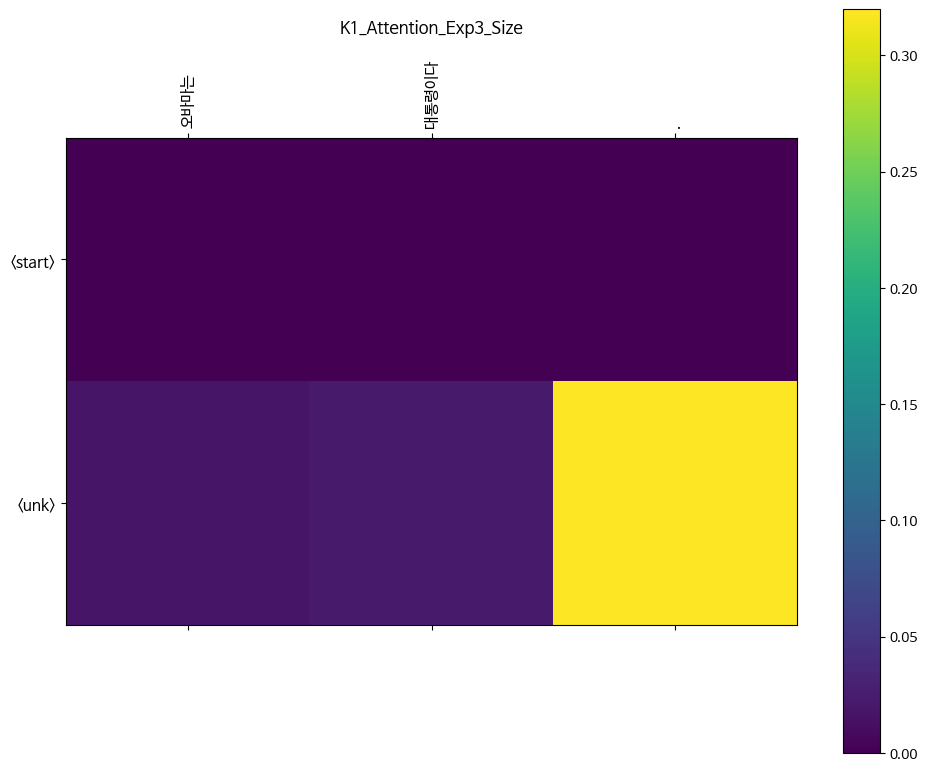

Attention Map 저장: K1_Attention_Exp3_Size.png

───────────────────────────────────────────────────────
Input      : 시민들은 도시 속에 산다.
Cleaned    : 시민들은 도시 속에 산다 .
Translation: <start> the <unk> of this year , i d hold back this morning , and they ve stopped checking for a few days , they knew all about them , <unk> said .


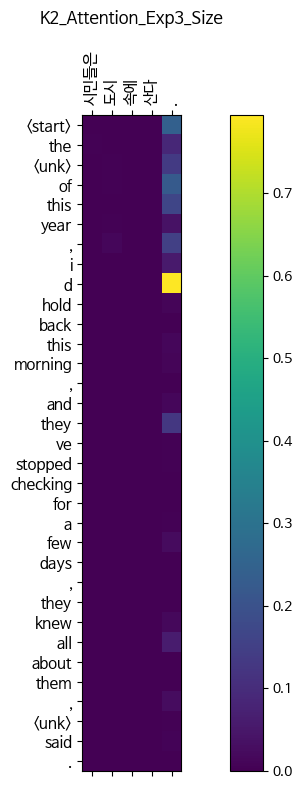

Attention Map 저장: K2_Attention_Exp3_Size.png

───────────────────────────────────────────────────────
Input      : 커피는 필요 없다.
Cleaned    : 커피는 필요 없다 .
Translation: <start> don t get carried away .


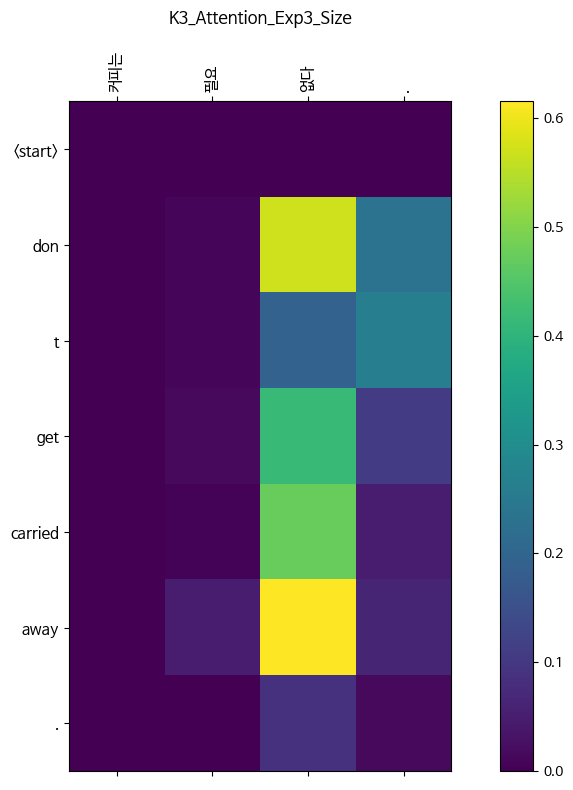

Attention Map 저장: K3_Attention_Exp3_Size.png

───────────────────────────────────────────────────────
Input      : 일곱 명의 사망자가 발생했다.
Cleaned    : 일곱 명의 사망자가 발생했다 .
Translation: <start> nine south korean workers are running in the worst eight region to escape high school , a total of .


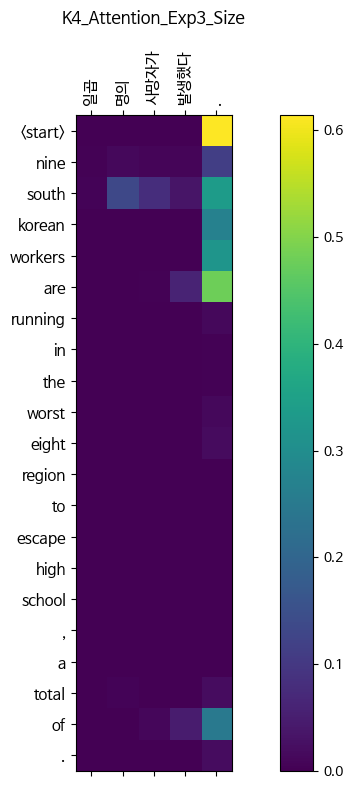

Attention Map 저장: K4_Attention_Exp3_Size.png



In [32]:
# 최종 번역 결과 + Attention Map 출력

BEST_MODEL_NAME = "Exp3_Size"
BEST_NUM_WORDS  = 15_000   # Exp3의 vocab 크기
BEST_EMB_DIM    = 256
BEST_HID_DIM    = 512

# tokenizer 새로 구축 (저장된 .pt와 동일한 vocab 조건으로)
_, final_kor_tokenizer = tokenize(kor_corpus, num_words=BEST_NUM_WORDS)
_, final_eng_tokenizer = tokenize(eng_corpus, num_words=BEST_NUM_WORDS)

# 모델 구조 생성 후 저장된 가중치 로드
final_model = build_model(
    input_dim     = len(final_kor_tokenizer),
    output_dim    = len(final_eng_tokenizer),
    emb_dim       = BEST_EMB_DIM,
    hid_dim       = BEST_HID_DIM,
    dropout       = 0.0,
    bidirectional = False,  # Exp3은 단방향
)
final_model.load_state_dict(
    torch.load(f"{BEST_MODEL_NAME}_model.pt", map_location=device)
)
final_model.eval()
print(f"✓ 불러온 모델: {BEST_MODEL_NAME}_model.pt\n")

print(f"[ 최종 번역 결과 & Attention Map — {BEST_MODEL_NAME} ]\n")
for i, sent in enumerate(TEST_SENTENCES, start=1):
    print(f"{'─' * 55}")
    translate_and_show(
        sent,
        final_model, final_kor_tokenizer, final_eng_tokenizer,
        max_len = MAX_LEN,
        title   = f"K{i}_Attention_{BEST_MODEL_NAME}",
    )
    print()

## 정리

**Phase 1 실험 결과 정리 (루브릭 요구 사항)**

**1. 에폭당 학습 시간**

| Experiment | Setting  | Time per Epoch | Parameters |
|------------|----------|----------------|------------|
| Exp1       | Baseline | 1:37           | 8.4M       |
| Exp2       | +Vocab   | 1:58           | 12.3M      |
| Exp3       | +Size    | 4:15           | 25.9M      |


- 단어 사전 크기를 10,000 에서 15,000으로 늘렸을 때 에폭당 시간이 약 21초 증가했다.

-  emb·hid를 128/256 → 256/512로 키웠을 때는 Exp1 대비 약 2.6배 증가했으며, 이는 파라미터 수가 약 3배 늘어났기 때문이다.


**2. Loss 수렴**

- 세 실험 모두 loss가 단조 감소하며 안정적으로 수렴했다. 에폭을 추가하면 수렴을 더 많이 했겠지만 학습 시간을 고려할 때 20 에폭이 최선이었다.

- 최종 loss는 Exp1(1.60) -> Exp2(1.49) -> Exp3(0.55) 순으로 개선되었으며 특히 Exp3에서 모델 크기 증가의 효과가 두드러졌다.

**3. 번역 품질**

- Exp1, 2는 20에폭 이후에도 <unk> 토큰 비율이 높고 문장 구조가 불안정했다.

- Exp3은 5에폭 시점부터 don't need to be overly 같이 부정문 구조를 일관되게 잡아내는 등 의미 패턴을 학습할 수 있음이 확인되었다.

- 다만 세 실험 모두 번역 품질이 기대에 미치지 못했는데, 이는 모델 구조의 한계도 있겠지만 학습 데이터의 도메인 편향(뉴스, 정치, 군사 중심)과 병렬 쌍 불완전성에서 (한국어 문장과 영어 문장이 정확히 1:1로 대응되지 않아 의미상 다른 문장이 쌍으로 묶인 경우) 기인한 것으로 판단된다.


**4. Attention Map 분석**

4개의 테스트 예문에 대해 Exp3_Size 모델의 Attention Map을 시각화했다.

- **K3("커피는 필요 없다")** 는 가장 긍정적인 케이스다. don, t, get, carried 토큰이 소스 문장의 "없" 토큰에 집중적으로 attention을 부여했으며, 부정 의미를 담은 핵심 형태소를 올바르게 참조했음을 확인할 수 있다. 번역 결과 (don't get carried away) 의 의미가 정확하지는 않지만 attention 메커니즘 자체는 정상 동작했다.

- K1, K2, K4는 모델이 한 토큰에만 의존해 집중적으로 높은 가중치를 부여했거나 도메인 편향 문제를 겪었음을 보여준다.

## 회고

- `torch compiler`로 학습 시간을 줄여본다고 해놓고 코드를 작성할 때는 그만 까먹었다. Exp4, 5를 진행해야 하니 모든 실험에 적용해서 학습 시간 비교를 수행할 것이다.

- 데이터에 틀린 번역이 상당히 많이 존재하는 것으로 보인다. 물론 하나씩 검수하는 방법도 있었겠지만 시간상 그렇게 하지는 못했다. 이 경우에 적용할 수 있는 번역 품질 검수 모델이 있는지 알아봐야겠다.

- 모델의 학습 결과를 어떻게 평가할 것인지 결정하기 어려웠다. 또 이번 과제처럼 데이터 수가 적어 validation set를 따로 두지 않고 모델을 학습할 경우 과적합 여부를 어떻게 판단할 수 있는지도 궁금했다. 이 2가지 의문에 대한 내 생각을 기록한다.
  
  * **어떻게 과적합 여부를 판단할 것인지**
 
    **1. training loss 곡선의 수렴 여부 확인**
 
    정상적인 학습이라면 에폭이 증가할수록 loss가 점점 감소하다가 완만하게 수렴하지만, 어느 순간부터 진동하거나 오히려 올라간다면 학습이 불안정하다는 신호다. validation set의 부재로 과적합 여부는 정확히 판단하기가 어렵지만 적어도 학습이 안정적으로 진행됐는지 여부는 확인이 가능하다.
   
    **2. 학습 데이터에 없는 문장으로 직접 번역해보기**
 
    모델이 학습 문장은 잘 번역하는데 새로운 문장에서 완전히 엉뚱한 결과가 나온다면 과적합 가능성이 높다고 할 수 있다. 본 프로젝트의 테스트 예문 4개가 이를 확인하는 역할을 한다.
 
  * **모델의 성능을 평가하기 위해 어떤 정량적 지표를 활용할 수 있는지**
 
    * **BLEU**

      예측 문장과 정답 문장의 n-gram 겹침 비율을 측정한다.
      계산이 빠르고 기계 번역 분야에서 널리 쓰인다는 장점이 있다.
      단점은 단어 순서에 민감하고 의미가 같아도 표현이 다르면 낮은 점수가 나온다는 것이다.
      
    * **METEOR**
   
      단순 겹침 외에 동의어, 어간 일치까지 고려해서 BLEU보다 사람의 평가와 상관관계가 높다는 장점이 있다. 특히 짧은 문장이나 어휘 변형이 많은 경우에 BLEU를 보완하는 역할을 한다.
   

      다만 이 두 지표 모두 학습 데이터로만 평가한다는 근본적인 한계가 있다. **train/val 분리 없이 나온 BLEU, METEOR 점수는 모델이 학습 데이터를 얼마나 잘 기억했는지를 측정하는 것이지, 일반화 성능을 측정하는 게 아니기 때문이다.** 그래서 점수가 높게 나와도 실제 번역 품질이 좋다고 단정할 수는 없다.